In [2]:
import numpy as np

from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

dataset = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=False,
)

dataset.end_trim = None
dataset.start_trim = None


In [6]:
from mreyemove.data.fmri_mixin import TissueType
from nilearn.image import image, resample_to_img
from sklearn.linear_model import LinearRegression
from mreyemove.preprocessing.eye_move import construct_dissimilarity_signal
from mreyemove.constants import EYE_SIGNAL_CONFOUNDS
from nilearn.masking import apply_mask
import pandas as pd 

signal_data = []
raw_signals = []
clean_signals = []

for subject in dataset.subjects:
    mask, _  = dataset.load_dseg_mask(subject=subject, tissue=TissueType.GRAY_MATTER)
    if mask is None:
        print(f"Couldn't find mask for {subject}")
        continue
    for _, run, _ in dataset.iter_run_events(subject=subject, run_inclusion=False):
        motion_params = dataset.load_confounds(subject, run, confound_names=EYE_SIGNAL_CONFOUNDS)
        
        # print(subject, run)
        # 
        raw_brain, _ = dataset.load_functional_image(subject=subject, run=run)
        mask_resampled = resample_to_img(mask, raw_brain, copy_header=True, force_resample=True, interpolation="nearest")
        # print(wm_mask.shape, raw_brain.shape)
        raw_timeseries = apply_mask(raw_brain, mask_resampled).T  # (voxels, timepoints)

        raw_signal = construct_dissimilarity_signal(
            data=raw_timeseries,
            tr=dataset.tr,
            subject=subject,
            run=run,
            confound_names=EYE_SIGNAL_CONFOUNDS,
            clean=False,
        )
        # raw_signals.append(raw_signal)
        
        # Fit model and save r-squared 
        # model_raw = LinearRegression().fit(motion_params, raw_signal)
        # r2_raw = model_raw.score(motion_params, raw_signal)
        # 
        
        clean_brain = image.clean_img(
            raw_brain,
            confounds=motion_params,
            detrend=False,
            standardize=False,
        )
        clean_timeseries = apply_mask(clean_brain, mask_resampled).T  # (voxels, timepoints)
                
        clean_signal = construct_dissimilarity_signal(
            data=clean_timeseries,
            tr=dataset.tr,
            subject=subject,
            run=run,
            confound_names=EYE_SIGNAL_CONFOUNDS,
            clean=False,
        )
        
        signal_data.append({
            'subject': subject,
            'run': run,
            'raw_signal': raw_signal,
            'clean_signal': clean_signal,
        })
        # clean_signals.append(clean_signal)
        # 
        # Fit model and save r-squared 
        # model_clean = LinearRegression().fit(motion_params, clean_wm_timeseries)
        # r2_clean = model_clean.score(motion_params, clean_wm_timeseries)
        
        
        # results.append({
        #     'subject': subject,
        #     'run': run,
        #     'r2_raw': r2_raw,
        #     'r2_clean': r2_clean,
        # })
        

# results_df = pd.DataFrame(results)


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_76845/254559905.py:26: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  wm_mask_resampled = resample_to_img(wm_mask, raw_brain, interpolation='nearest')
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_76845/254559905.py:26: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  wm_mask_resampled = resample_to_img(wm_mask, raw_brain, interpolation='nearest')
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_76845/254559905.py:45: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects thi

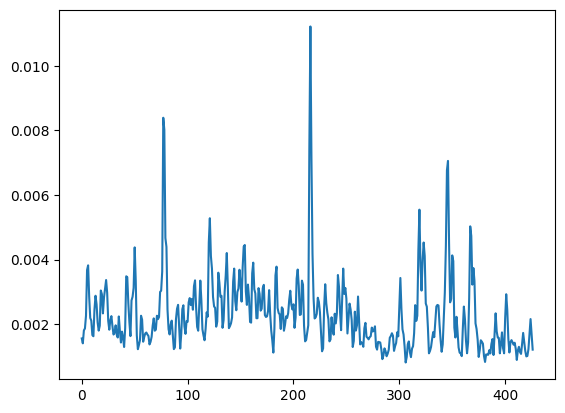

In [7]:
from matplotlib import pyplot as plt
plt.plot(signal_data[0]["raw_signal"])

In [8]:

dissim_results = []

for data in signal_data:
    subject = data['subject']
    run = data['run']
    motion = dataset.load_confounds(subject, run, confound_names=EYE_SIGNAL_CONFOUNDS).iloc[1:-1]
    
    r2_raw = LinearRegression().fit(motion, data['raw_signal']).score(motion, data['raw_signal'])
    r2_clean = LinearRegression().fit(motion, data['clean_signal']).score(motion, data['clean_signal'])
    
    dissim_results.append({
        'subject': subject,
        'run': run,
        'r2_raw_dissim': r2_raw,
        'r2_clean_dissim': r2_clean,
    })
    

dissim_df = pd.DataFrame(dissim_results)
print(f"\nWM Dissimilarity - Raw: {dissim_df['r2_raw_dissim'].mean():.3f}")
print(f"WM Dissimilarity - Clean: {dissim_df['r2_clean_dissim'].mean():.3f}")



WM Dissimilarity - Raw: 0.600
WM Dissimilarity - Clean: 0.465


In [5]:
print(f"\nCSF Dissimilarity - Raw: {dissim_df['r2_raw_dissim'].mean():.3f}")
print(f"CSF Dissimilarity - Clean: {dissim_df['r2_clean_dissim'].mean():.3f}")



CSF Dissimilarity - Raw: 0.588
CSF Dissimilarity - Clean: 0.442


In [3]:
def construct_dissimilarity_signal(
        data: np.ndarray,
) -> np.ndarray:
    # Reshape to 2D: (num_voxels, timepoints)
    reshaped_data = data.reshape(-1, data.shape[-1])  # (voxels, timepoints)

    # Remove voxels that are zero across all timepoints
    nonzero_voxel_mask = ~(reshaped_data == 0).all(axis=1)
    filtered_data = reshaped_data[nonzero_voxel_mask]

    # Compute voxel-wise correlation across consecutive TRs
    corrmat = np.corrcoef(
        filtered_data, rowvar=False
    )  # Columns (TRs) represent variables to compute corr over

    # Extract values just below the diagonal: elements at (i+1, i)
    below_diagonal = corrmat[1:, :-1]
    sub_diagonal_values = below_diagonal[
        np.arange(below_diagonal.shape[0]), np.arange(below_diagonal.shape[0])
    ]
    dissimilarity = 1 - sub_diagonal_values

    # Shift half TR to align with functional images
    dissimilarity = 0.5 * (dissimilarity[:-1] + dissimilarity[1:])


    return dissimilarity

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_24275/559721805.py:35: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_brain = image.clean_img(


<Figure size 640x480 with 0 Axes>

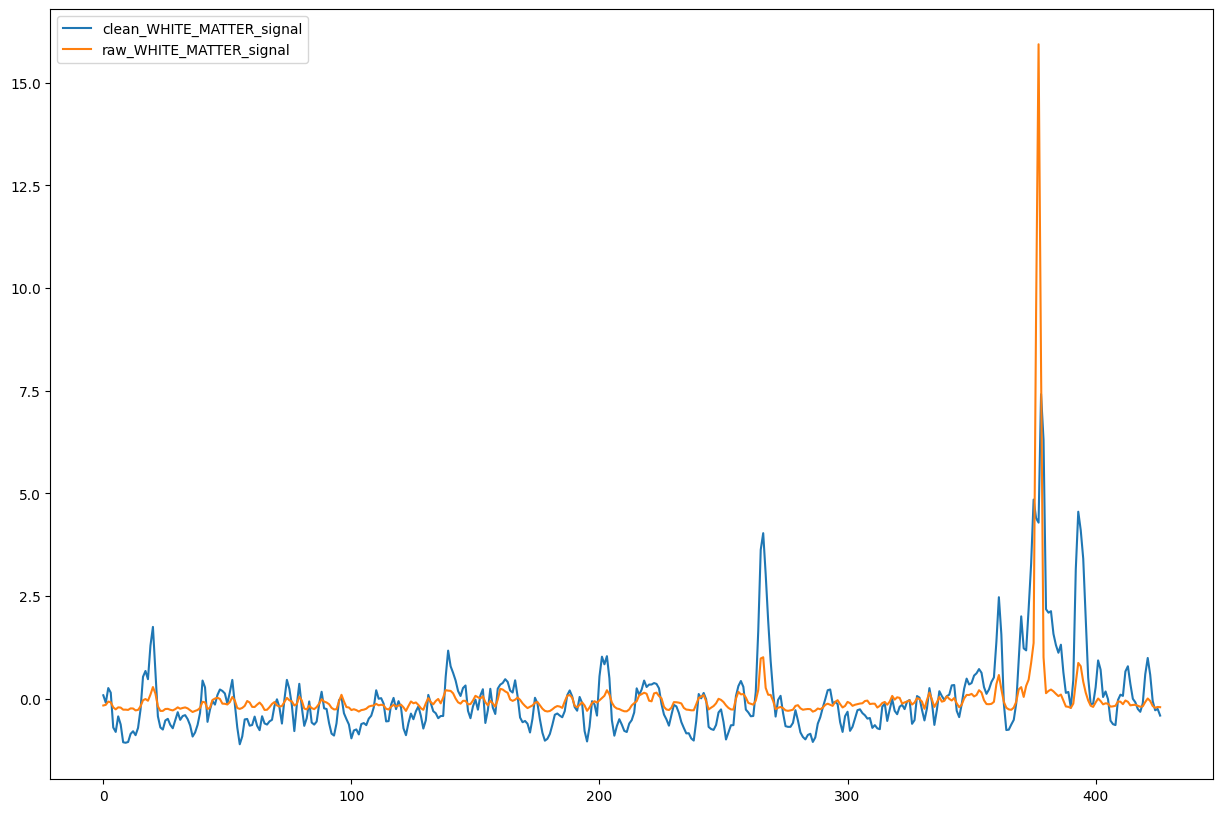

In [4]:

from scipy.stats import zscore
from nilearn import plotting
from mreyemove.data.fmri_mixin import TissueType
from nilearn.image import image, resample_to_img
from sklearn.linear_model import LinearRegression
from mreyemove.constants import EYE_SIGNAL_CONFOUNDS
from nilearn.masking import apply_mask
from matplotlib import pyplot as plt
import pandas as pd 

signal_data = []
raw_signals = []
clean_signals = []
dataset.end_trim = None
dataset.start_trim = None


subject = "06"
run = "2"
tissue = TissueType.WHITE_MATTER
mask, _  = dataset.load_dseg_mask(subject=subject, tissue=tissue)
motion_params = dataset.load_confounds(subject, run, confound_names=EYE_SIGNAL_CONFOUNDS)

raw_brain, _ = dataset.load_functional_image(subject=subject, run=run)
mask_resampled = resample_to_img(mask, raw_brain, copy_header=True, force_resample=True, interpolation="nearest")

# plotting.view_img(wm_mask_resampled, bg_img=image.mean_img(raw_brain, copy_header=True), resampling_interpolation="nearest", cmap="Oranges")
raw_timeseries = apply_mask(raw_brain, mask_resampled)  # (timepoints, voxels)
raw_data = raw_timeseries.T  # (voxels, timepoints)

raw_signal = construct_dissimilarity_signal(
    data=raw_data,
)

clean_brain = image.clean_img(
            raw_brain,
            confounds=motion_params,
            detrend=False,
            standardize=None,
        )
clean_timeseries = apply_mask(clean_brain, mask_resampled)  # (voxels, timepoints)
clean_data = clean_timeseries.T  # (voxels, timepoints)
   
clean_signal = construct_dissimilarity_signal(
    data=clean_data,
)
plt.set_cmap("Set3")
f, axs = plt.subplots(1,1, figsize=(15,10))
# axs.plot(zscore(motion_params["framewise_displacement"].to_numpy()[1:-1]), label="FD")
axs.plot(zscore(clean_signal), label=f"clean_{tissue.name}_signal")
axs.plot(zscore(raw_signal), label=f"raw_{tissue.name}_signal")
axs.legend()



In [8]:

raw_brain, _ = dataset.load_functional_image(subject=subject, run=run)

confound_names = [
    f"trans_{i}" for i in ("x", "y", "z")
]
confound_names.extend([
    f"trans_{i}_derivative1" for i in ("x", "y", "z")
])
confound_names.extend(
    [f"rot_{i}" for i in ("x", "y", "z")]
)
confound_names.extend(
    [f"rot_{i}_derivative1" for i in ("x", "y", "z")]
)
confound_names.extend(["framewise_displacement"])


motion_params = dataset.load_confounds(
    confound_names=confound_names,
    subject=subject,
    run=run,
)

clean_brain = image.clean_img(
            raw_brain,
            confounds=motion_params,
            detrend=False,
            standardize=False,
        )

brain_data = clean_brain.get_fdata()

brain_diss = construct_dissimilarity_signal(brain_data)
# mreye_signal,_ = dataset.load_eye_move(subject=subject, run=run, desc_add="clean-voxels")
# 
# plt.plot(raw_brain_diss, label="brain_diss")
# plt.plot(mreye_signal, label="eye_diss")
# plt.legend()

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_24275/844016470.py:24: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_brain = image.clean_img(


In [9]:
    
trim_mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
)


Global dissimilarity : FD corr 0.7638586930393311


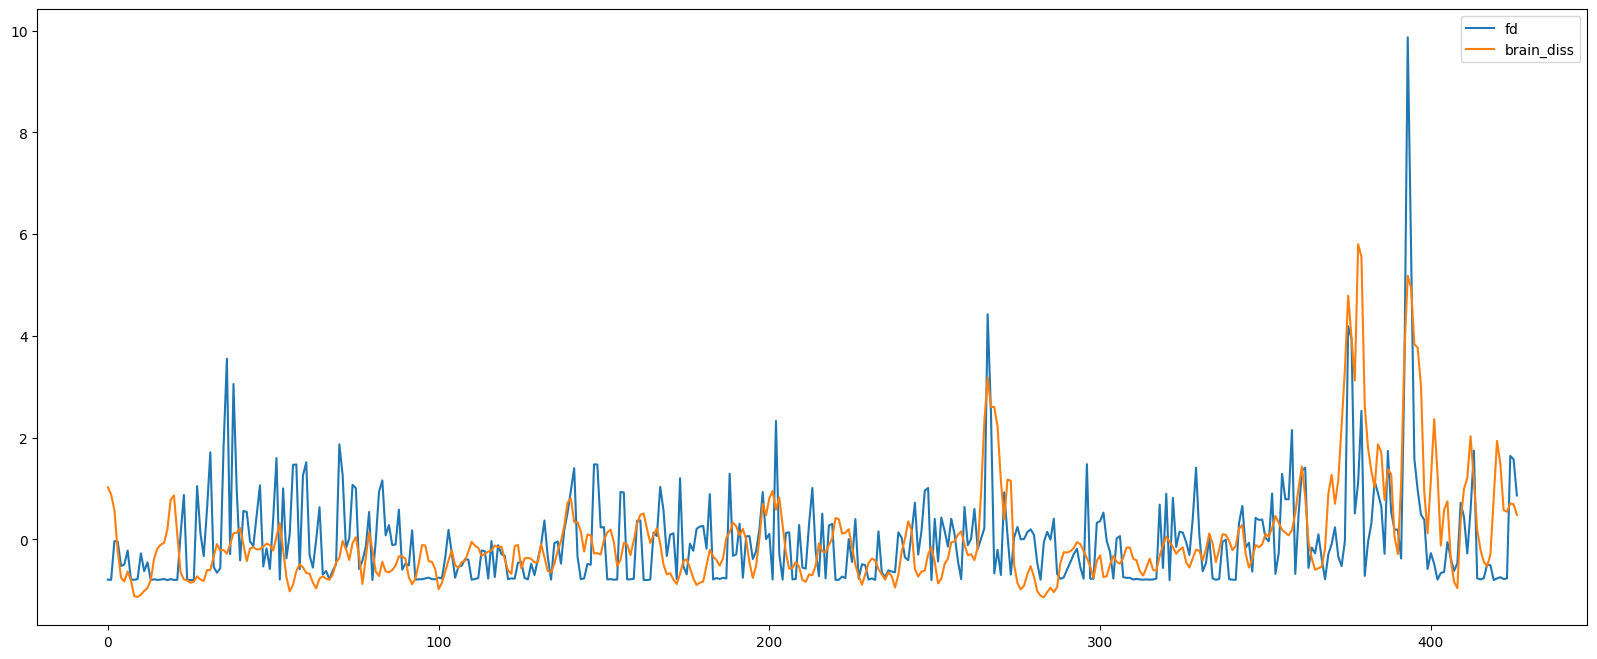

In [10]:

from nilearn.signal import clean

subject = "06"
run = "2"


motion_params = trim_mrio.load_confounds(
    confound_names=confound_names,
    subject=subject,
    run=run,
)

mreye_signal, _ = trim_mrio.load_eye_move(subject=subject, run=run, desc_add="clean-voxels")
confounds = trim_mrio.load_confounds(subject=subject, run=run, confound_names=EYE_SIGNAL_CONFOUNDS)
# confounds["global_framewise_diss"] = raw_brain_diss
# signal_2d = mreye_signal.reshape(-1, 1)
# cleaned_signal = clean(
#                 signal_2d,
#                 confounds=confounds,
#                 standardize=False,
#                 detrend=False,
#                 filter=False,
#                 t_r=None,
#             ).ravel()
cleaned_signal = mreye_signal - brain_diss
# plt.plot(zscore(cleaned_signal), label="new_eye")
f, ax = plt.subplots(1,1,figsize=(20, 8))
# ax.plot(zscore(convolved), label="convolved")
# ax.plot(convolve_mreyemove(orig, tr=2.1), label="original")
# ax.plot(convolve_mreyemove(scrubbed, tr=2.1), label="scrubbed")
ax.plot(zscore(motion_params["trans_x_derivative1"].abs()), label="fd")
ax.plot(zscore(brain_diss), label="brain_diss")
print("Global dissimilarity : FD corr", np.corrcoef(brain_diss, mreye_signal)[0,1])
ax.legend()

/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



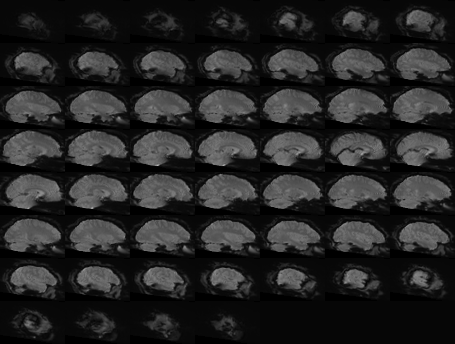
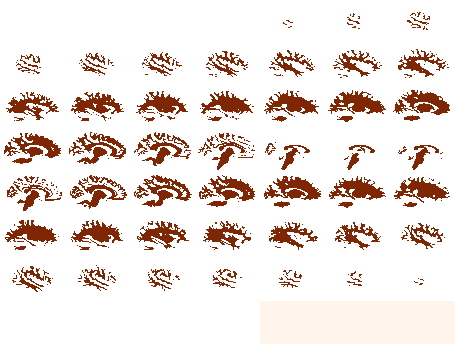

In [23]:
plotting.view_img(mask_resampled, bg_img=image.mean_img(raw_brain, copy_header=True),resampling_interpolation="nearest", cmap="Oranges", symmetric_cmap=False)

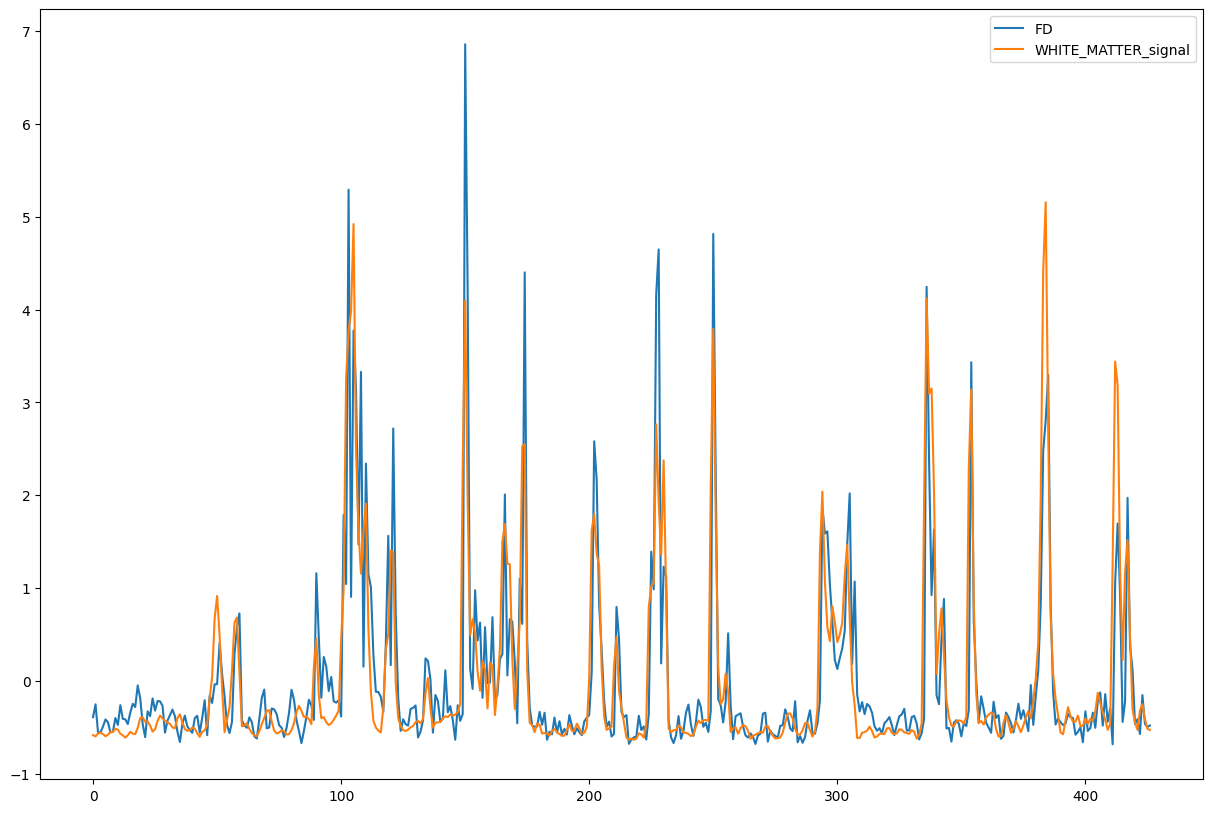

In [56]:
plot_dataset = dataset = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=False,
    
)


confound_names = [
    f"trans_{i}" for i in ("x", "y", "z")
]
confound_names.extend([
    f"trans_{i}_derivative1" for i in ("x", "y", "z")
])
confound_names.extend(
    [f"rot_{i}" for i in ("x", "y", "z")]
)
confound_names.extend(
    [f"rot_{i}_derivative1" for i in ("x", "y", "z")]
)
confound_names.extend(["framewise_displacement"])


motion_params = plot_dataset.load_confounds(
    confound_names=confound_names,
    subject=subject,
    run=run,
)

mreye_signal,_ = dataset.load_eye_move(subject=subject, run=run, desc_add="raw")

f, axs = plt.subplots(1,1, figsize=(15,10))
axs.plot(zscore(motion_params["framewise_displacement"].to_numpy()), label="FD")
axs.plot(zscore(signal), label=f"{tissue.name}_signal")
# axs.plot(zscore(mreye_signal), label="raw_eye_signal", color="r")
axs.legend()



In [13]:
import numpy as np 
# np.corrcoef(motion_params["framewise_displacement"].to_numpy()[1:-1], signal)[0,1]
np.corrcoef(clean_signal, signal)[0,1]

0.9415906439876695

In [73]:
motion_params = dataset.load_confounds(
    confound_names=confound_names,
    subject=subject,
    run=run,
) 
model_raw = LinearRegression().fit(motion_params, raw_timeseries)
r2_raw = model_raw.score(motion_params, raw_timeseries)
model_clean = LinearRegression().fit(motion_params, clean_timeseries)
r2_clean = model_clean.score(motion_params, clean_timeseries)

print(r2_raw, r2_clean)
# r2_raw = LinearRegression().fit(motion_params, raw_timeseries.T).score(motion_params, raw_timeseries.T)
# r2_clean = LinearRegression().fit(motion_params, clean_timeseries.T).score(motion_params, clean_timeseries.T)

0.4146416815116337 0.0032445187298978826


In [75]:
motion_params = plot_dataset.load_confounds(
    confound_names=confound_names,
    subject=subject,
    run=run,
).iloc[1: -1]
model_raw = LinearRegression().fit(motion_params, raw_signal)
r2_raw = model_raw.score(motion_params, raw_signal)
model_clean = LinearRegression().fit(motion_params, clean_signal)
r2_clean = model_clean.score(motion_params, clean_signal)

print(r2_raw, r2_clean)
# r2_raw = LinearRegression().fit(motion_params, raw_timeseries.T).score(motion_params, raw_timeseries.T)
# r2_clean = LinearRegression().fit(motion_params, clean_timeseries.T).score(motion_params, clean_timeseries.T)

0.7023269572919396 0.5955244399747615


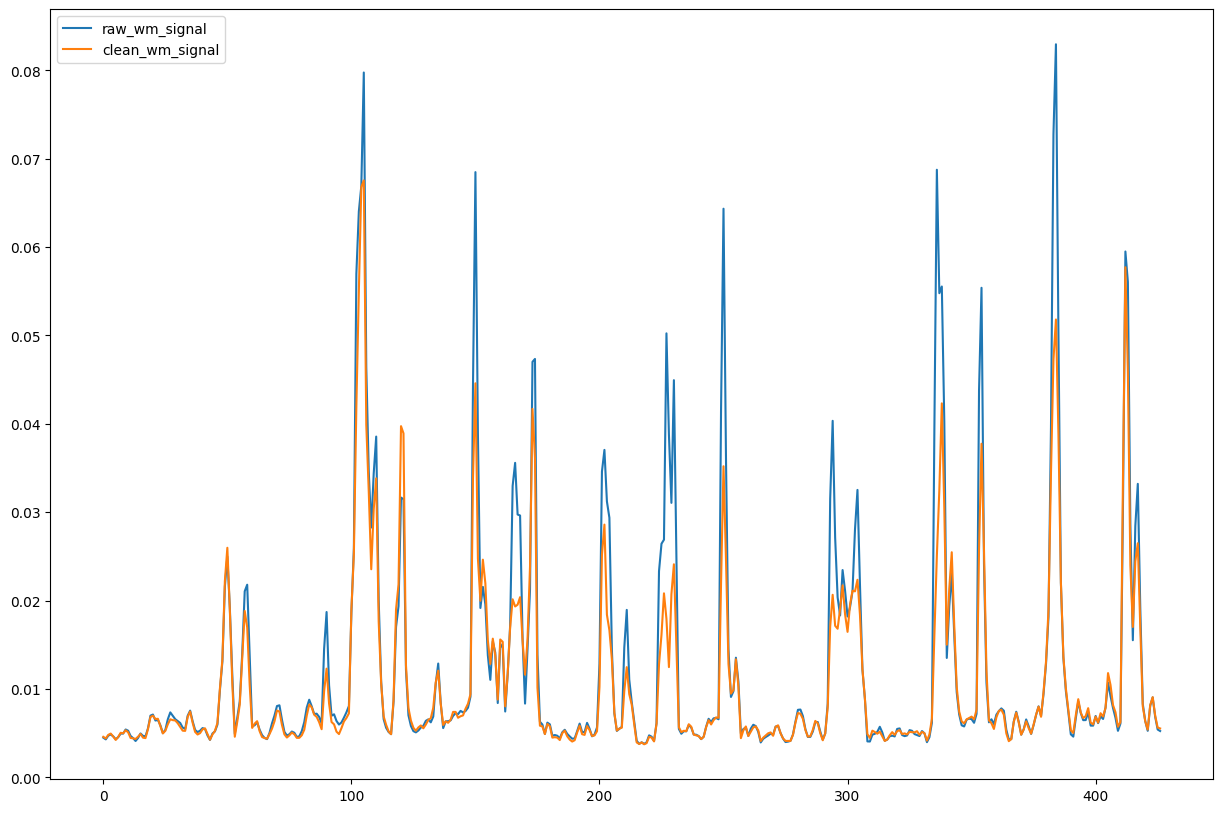

In [34]:
mreye_signal,_ = dataset.load_eye_move(subject=subject, run=run, desc_add="clean-voxels")

f, axs = plt.subplots(1,1, figsize=(15,10))

axs.plot(raw_signal, label="raw_wm_signal")
axs.plot(clean_signal, label="clean_wm_signal")
# axs.plot(mreye_signal, label="eye_signal")
axs.legend()

In [19]:
np.corrcoef(clean_signal, mreye_signal)

array([[1.        , 0.62912561],
       [0.62912561, 1.        ]])